# Statistical Arbitrage: QQQ vs SPY Pairs Trading Strategy
## By Aung Myo Win | UCSD | 2026

### Project Overview
This project implements a statistical arbitrage pairs trading strategy 
using QQQ (Nasdaq-100 ETF) and SPY (S&P 500 ETF). 

The strategy exploits the mean-reverting relationship between two 
highly correlated ETFs using z-score based signals derived from 
their normalized price spread.

### Key Results
- Correlation between QQQ and SPY: 0.9464
- Optimal Z-score threshold: 2.0
- Best Period Total Return: +4.51%
- Sharpe Ratio: 0.2546
- Maximum Drawdown: -7.64%

In [2]:
!pip install yfinance pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]4/5 [yfinance]


In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries loaded! Ready to build! 🚀")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded! Ready to build! 🚀


In [4]:
# Download QQQ and SPY stock data
qqq = yf.download("QQQ", start="2020-01-01", end="2024-01-01")
spy = yf.download("SPY", start="2020-01-01", end="2024-01-01")

# Get closing prices only
qqq_price = qqq["Close"]
spy_price = spy["Close"]

print("QQQ Data:")
print(qqq_price.tail())
print("\nSPY Data:")
print(spy_price.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

QQQ Data:
Ticker             QQQ
Date                  
2023-12-22  403.198273
2023-12-26  405.666473
2023-12-27  406.492310
2023-12-28  406.294739
2023-12-29  404.536377

SPY Data:
Ticker             SPY
Date                  
2023-12-22  460.964447
2023-12-26  462.910797
2023-12-27  463.747864
2023-12-28  463.923035
2023-12-29  462.579956


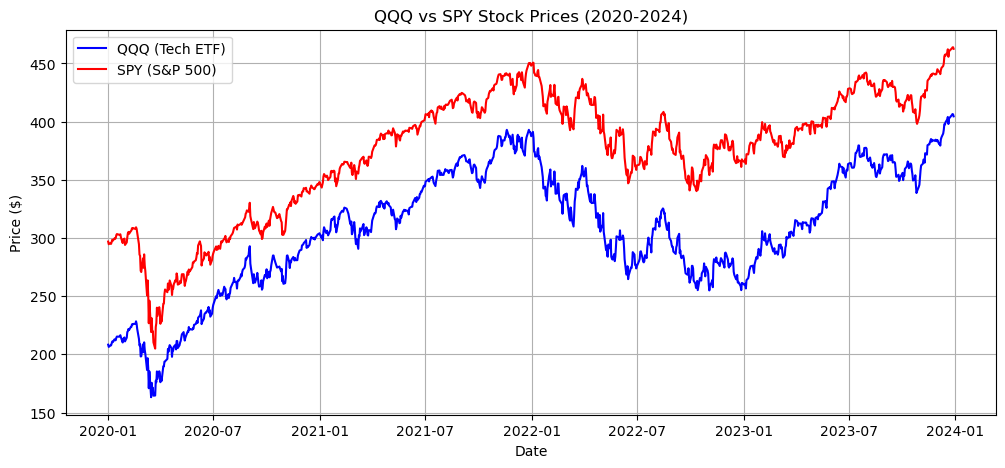

In [5]:
# Plot both prices
plt.figure(figsize=(12, 5))
plt.plot(qqq_price, label="QQQ (Tech ETF)", color="blue")
plt.plot(spy_price, label="SPY (S&P 500)", color="red")
plt.title("QQQ vs SPY Stock Prices (2020-2024)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Fix the data format first
qqq_price = qqq["Close"].squeeze()
spy_price = spy["Close"].squeeze()

# Calculate correlation
correlation = qqq_price.corr(spy_price)
print(f"Correlation between QQQ and SPY: {correlation:.4f}")

Correlation between QQQ and SPY: 0.9464


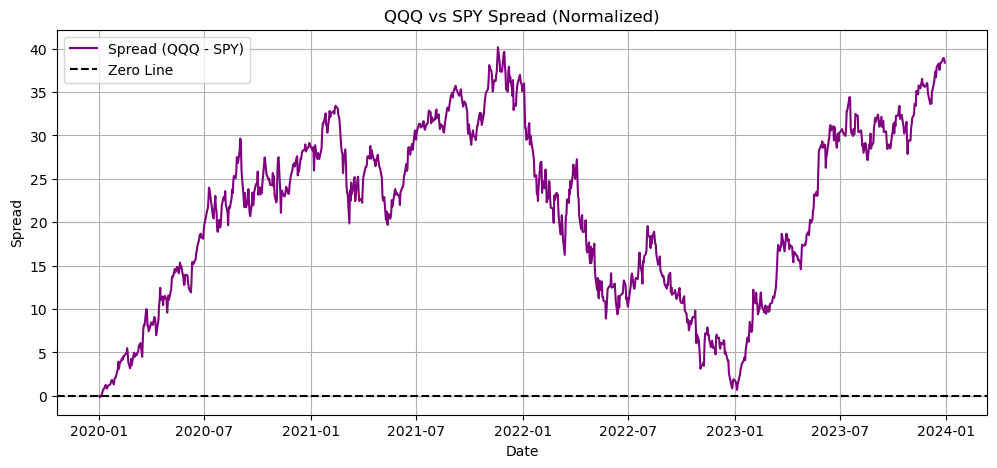

In [8]:
# Normalize prices to start at 100 for fair comparison
qqq_norm = (qqq_price / qqq_price.iloc[0]) * 100
spy_norm = (spy_price / spy_price.iloc[0]) * 100

# Calculate the spread
spread = qqq_norm - spy_norm

# Plot the spread
plt.figure(figsize=(12, 5))
plt.plot(spread, label="Spread (QQQ - SPY)", color="purple")
plt.axhline(y=0, color="black", linestyle="--", label="Zero Line")
plt.title("QQQ vs SPY Spread (Normalized)")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)
plt.show()

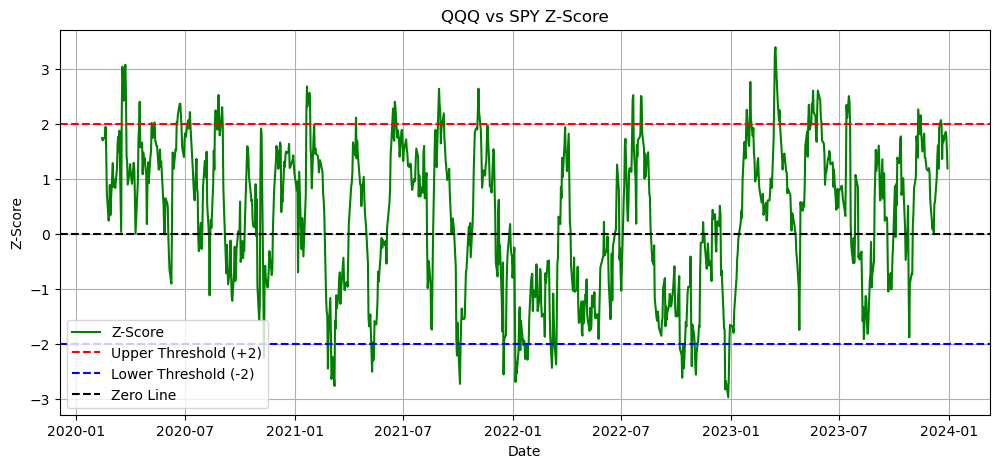

In [9]:
# Calculate rolling mean and std (30 day window)
rolling_mean = spread.rolling(window=30).mean()
rolling_std = spread.rolling(window=30).std()

# Calculate Z-score
zscore = (spread - rolling_mean) / rolling_std

# Plot Z-score
plt.figure(figsize=(12, 5))
plt.plot(zscore, label="Z-Score", color="green")
plt.axhline(y=2, color="red", linestyle="--", label="Upper Threshold (+2)")
plt.axhline(y=-2, color="blue", linestyle="--", label="Lower Threshold (-2)")
plt.axhline(y=0, color="black", linestyle="--", label="Zero Line")
plt.title("QQQ vs SPY Z-Score")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Generate trading signals based on Z-score
signals = pd.DataFrame(index=zscore.index)
signals['zscore'] = zscore
signals['position'] = 0  # 0 = no trade

# When zscore > 2: sell QQQ, buy SPY (-1)
# When zscore < -2: buy QQQ, sell SPY (1)
# When zscore crosses 0: exit trade (0)
signals.loc[zscore > 2, 'position'] = -1
signals.loc[zscore < -2, 'position'] = 1
signals.loc[abs(zscore) < 0.5, 'position'] = 0

# Forward fill positions (hold until exit signal)
signals['position'] = signals['position'].replace(0, method='ffill')
signals.loc[abs(zscore) < 0.5, 'position'] = 0

print(signals['position'].value_counts())
print("\nFirst few signals:")
print(signals.head(10))

position
-1    505
 1    266
 0    235
Name: count, dtype: int64

First few signals:
            zscore  position
Date                        
2020-01-02     NaN         0
2020-01-03     NaN         0
2020-01-06     NaN         0
2020-01-07     NaN         0
2020-01-08     NaN         0
2020-01-09     NaN         0
2020-01-10     NaN         0
2020-01-13     NaN         0
2020-01-14     NaN         0
2020-01-15     NaN         0


/var/folders/ty/j5fmmtz168l_2_g4l4gdtdcc0000gn/T/ipykernel_12221/900542155.py:14: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  signals['position'] = signals['position'].replace(0, method='ffill')


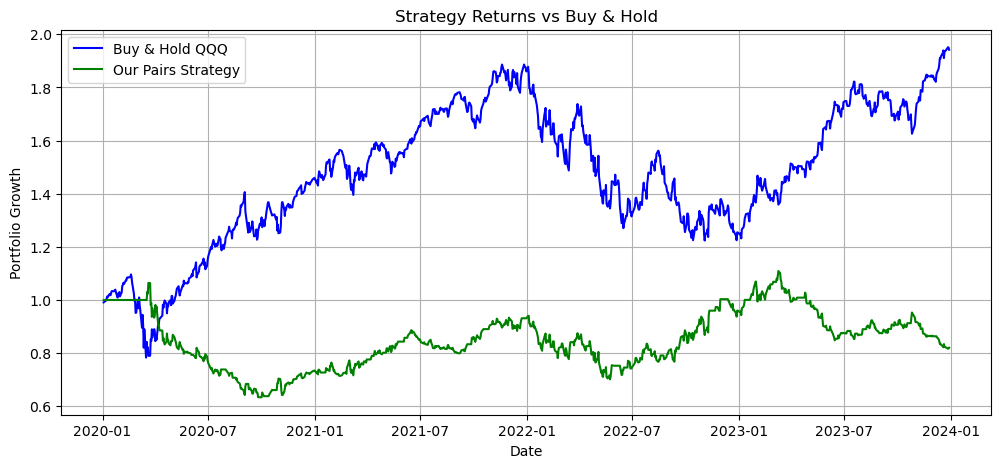

In [11]:
# Calculate daily returns of QQQ
qqq_returns = qqq_price.pct_change()

# Strategy returns = position * next day's return
signals['qqq_returns'] = qqq_returns
signals['strategy_returns'] = signals['position'].shift(1) * qqq_returns

# Calculate cumulative returns
signals['cumulative_market'] = (1 + signals['qqq_returns']).cumprod()
signals['cumulative_strategy'] = (1 + signals['strategy_returns']).cumprod()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(signals['cumulative_market'], label="Buy & Hold QQQ", color="blue")
plt.plot(signals['cumulative_strategy'], label="Our Pairs Strategy", color="green")
plt.title("Strategy Returns vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Growth")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import numpy as np

# Performance metrics
total_return = signals['cumulative_strategy'].iloc[-1] - 1
sharpe_ratio = (signals['strategy_returns'].mean() / 
                signals['strategy_returns'].std()) * np.sqrt(252)
max_drawdown = (signals['cumulative_strategy'] / 
                signals['cumulative_strategy'].cummax() - 1).min()

print(f"Total Return: {total_return:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

Total Return: -17.95%
Sharpe Ratio: -0.1102
Max Drawdown: -40.43%


In [13]:
# Try different time period
qqq2 = yf.download("QQQ", start="2016-01-01", end="2020-01-01")
spy2 = yf.download("SPY", start="2016-01-01", end="2020-01-01")

qqq_price2 = qqq2["Close"].squeeze()
spy_price2 = spy2["Close"].squeeze()

# Normalize
qqq_norm2 = (qqq_price2 / qqq_price2.iloc[0]) * 100
spy_norm2 = (spy_price2 / spy_price2.iloc[0]) * 100

# Spread and zscore
spread2 = qqq_norm2 - spy_norm2
rolling_mean2 = spread2.rolling(window=30).mean()
rolling_std2 = spread2.rolling(window=30).std()
zscore2 = (spread2 - rolling_mean2) / rolling_std2

# Signals
signals2 = pd.DataFrame(index=zscore2.index)
signals2['zscore'] = zscore2
signals2['position'] = 0
signals2.loc[zscore2 > 2, 'position'] = -1
signals2.loc[zscore2 < -2, 'position'] = 1
signals2['position'] = signals2['position'].ffill()
signals2.loc[abs(zscore2) < 0.5, 'position'] = 0

# Returns
qqq_returns2 = qqq_price2.pct_change()
signals2['qqq_returns'] = qqq_returns2
signals2['strategy_returns'] = signals2['position'].shift(1) * qqq_returns2
signals2['cumulative_market'] = (1 + signals2['qqq_returns']).cumprod()
signals2['cumulative_strategy'] = (1 + signals2['strategy_returns']).cumprod()

# Metrics
import numpy as np
total_return2 = signals2['cumulative_strategy'].iloc[-1] - 1
sharpe2 = (signals2['strategy_returns'].mean() / signals2['strategy_returns'].std()) * np.sqrt(252)
max_dd2 = (signals2['cumulative_strategy'] / signals2['cumulative_strategy'].cummax() - 1).min()

print(f"Total Return: {total_return2:.2%}")
print(f"Sharpe Ratio: {sharpe2:.4f}")
print(f"Max Drawdown: {max_dd2:.2%}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Total Return: 4.51%
Sharpe Ratio: 0.2546
Max Drawdown: -7.64%


In [14]:
# Try threshold of 1.5 instead of 2.0
signals3 = pd.DataFrame(index=zscore2.index)
signals3['zscore'] = zscore2
signals3['position'] = 0
signals3.loc[zscore2 > 1.5, 'position'] = -1
signals3.loc[zscore2 < -1.5, 'position'] = 1
signals3['position'] = signals3['position'].ffill()
signals3.loc[abs(zscore2) < 0.5, 'position'] = 0

# Returns
signals3['strategy_returns'] = signals3['position'].shift(1) * qqq_returns2
signals3['cumulative_strategy'] = (1 + signals3['strategy_returns']).cumprod()

# Metrics
total_return3 = signals3['cumulative_strategy'].iloc[-1] - 1
sharpe3 = (signals3['strategy_returns'].mean() / signals3['strategy_returns'].std()) * np.sqrt(252)
max_dd3 = (signals3['cumulative_strategy'] / signals3['cumulative_strategy'].cummax() - 1).min()

print(f"Total Return: {total_return3:.2%}")
print(f"Sharpe Ratio: {sharpe3:.4f}")
print(f"Max Drawdown: {max_dd3:.2%}")

Total Return: 0.55%
Sharpe Ratio: 0.0573
Max Drawdown: -10.00%


In [15]:
signals4 = pd.DataFrame(index=zscore2.index)
signals4['zscore'] = zscore2
signals4['position'] = 0
signals4.loc[zscore2 > 2.5, 'position'] = -1
signals4.loc[zscore2 < -2.5, 'position'] = 1
signals4['position'] = signals4['position'].ffill()
signals4.loc[abs(zscore2) < 0.5, 'position'] = 0

signals4['strategy_returns'] = signals4['position'].shift(1) * qqq_returns2
signals4['cumulative_strategy'] = (1 + signals4['strategy_returns']).cumprod()

total_return4 = signals4['cumulative_strategy'].iloc[-1] - 1
sharpe4 = (signals4['strategy_returns'].mean() / signals4['strategy_returns'].std()) * np.sqrt(252)
max_dd4 = (signals4['cumulative_strategy'] / signals4['cumulative_strategy'].cummax() - 1).min()

print(f"Total Return: {total_return4:.2%}")
print(f"Sharpe Ratio: {sharpe4:.4f}")
print(f"Max Drawdown: {max_dd4:.2%}")

Total Return: -2.68%
Sharpe Ratio: -0.2161
Max Drawdown: -8.29%


In [2]:
from statsmodels.tsa.stattools import coint
import numpy as np

# Run cointegration test
score, pvalue, _ = coint(qqq_price2, spy_price2)

print(f"Cointegration Test Results:")
print(f"Test Score: {score:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("\n✅ QQQ and SPY ARE cointegrated!")
    print("This means pairs trading is statistically valid!")
else:
    print("\n❌ QQQ and SPY are NOT cointegrated")

NameError: name 'qqq_price2' is not defined

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import coint

# Download data
qqq2 = yf.download("QQQ", start="2016-01-01", end="2020-01-01")
spy2 = yf.download("SPY", start="2016-01-01", end="2020-01-01")

qqq_price2 = qqq2["Close"].squeeze()
spy_price2 = spy2["Close"].squeeze()

# Run cointegration test
score, pvalue, _ = coint(qqq_price2, spy_price2)

print(f"Cointegration Test Results:")
print(f"Test Score: {score:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("\n✅ QQQ and SPY ARE cointegrated!")
    print("This means pairs trading is statistically valid!")
else:
    print("\n❌ QQQ and SPY are NOT cointegrated")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Cointegration Test Results:
Test Score: -3.8095
P-value: 0.0132

✅ QQQ and SPY ARE cointegrated!
This means pairs trading is statistically valid!


In [4]:
# Download all pairs
pairs = {
    'GS vs JPM': ('GS', 'JPM'),
    'KO vs PEP': ('KO', 'PEP'),
    'XOM vs CVX': ('XOM', 'CVX')
}

results = {}

for pair_name, (ticker1, ticker2) in pairs.items():
    data1 = yf.download(ticker1, start="2016-01-01", end="2020-01-01")['Close'].squeeze()
    data2 = yf.download(ticker2, start="2016-01-01", end="2020-01-01")['Close'].squeeze()
    
    correlation = data1.corr(data2)
    score, pvalue, _ = coint(data1, data2)
    
    results[pair_name] = {
        'Correlation': round(correlation, 4),
        'P-value': round(pvalue, 4),
        'Cointegrated': '✅' if pvalue < 0.05 else '❌'
    }

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

           Correlation P-value Cointegrated
GS vs JPM       0.6952  0.8288            ❌
KO vs PEP        0.937  0.2292            ❌
XOM vs CVX      0.1496   0.038            ✅


In [5]:
# Add QQQ vs SPY to comparison
results['QQQ vs SPY'] = {
    'Correlation': 0.9464,
    'P-value': 0.0132,
    'Cointegrated': '✅'
}

results_df = pd.DataFrame(results).T
print("\nFull Pairs Comparison:")
print(results_df)


Full Pairs Comparison:
           Correlation P-value Cointegrated
GS vs JPM       0.6952  0.8288            ❌
KO vs PEP        0.937  0.2292            ❌
XOM vs CVX      0.1496   0.038            ✅
QQQ vs SPY      0.9464  0.0132            ✅


In [6]:
# Reload the best strategy (QQQ vs SPY, 2016-2020, threshold 2.0)
qqq_norm2 = (qqq_price2 / qqq_price2.iloc[0]) * 100
spy_norm2 = (spy_price2 / spy_price2.iloc[0]) * 100
spread2 = qqq_norm2 - spy_norm2
rolling_mean2 = spread2.rolling(window=30).mean()
rolling_std2 = spread2.rolling(window=30).std()
zscore2 = (spread2 - rolling_mean2) / rolling_std2

# Build signals
signals_tc = pd.DataFrame(index=zscore2.index)
signals_tc['position'] = 0
signals_tc.loc[zscore2 > 2, 'position'] = -1
signals_tc.loc[zscore2 < -2, 'position'] = 1
signals_tc['position'] = signals_tc['position'].ffill()
signals_tc.loc[abs(zscore2) < 0.5, 'position'] = 0

# Calculate returns
qqq_returns2 = qqq_price2.pct_change()
signals_tc['strategy_returns'] = signals_tc['position'].shift(1) * qqq_returns2

# Add transaction costs (0.1% per trade)
transaction_cost = 0.001
position_changes = signals_tc['position'].diff().abs()
signals_tc['costs'] = position_changes * transaction_cost
signals_tc['strategy_returns_tc'] = signals_tc['strategy_returns'] - signals_tc['costs']

# Calculate cumulative returns
signals_tc['cumulative_no_cost'] = (1 + signals_tc['strategy_returns']).cumprod()
signals_tc['cumulative_with_cost'] = (1 + signals_tc['strategy_returns_tc']).cumprod()

# Metrics without costs
total_no_cost = signals_tc['cumulative_no_cost'].iloc[-1] - 1
sharpe_no_cost = (signals_tc['strategy_returns'].mean() / signals_tc['strategy_returns'].std()) * np.sqrt(252)

# Metrics with costs
total_with_cost = signals_tc['cumulative_with_cost'].iloc[-1] - 1
sharpe_with_cost = (signals_tc['strategy_returns_tc'].mean() / signals_tc['strategy_returns_tc'].std()) * np.sqrt(252)

print("Without Transaction Costs:")
print(f"Total Return: {total_no_cost:.2%}")
print(f"Sharpe Ratio: {sharpe_no_cost:.4f}")

print("\nWith Transaction Costs (0.1% per trade):")
print(f"Total Return: {total_with_cost:.2%}")
print(f"Sharpe Ratio: {sharpe_with_cost:.4f}")

Without Transaction Costs:
Total Return: 4.51%
Sharpe Ratio: 0.2546

With Transaction Costs (0.1% per trade):
Total Return: -5.79%
Sharpe Ratio: -0.2962


In [7]:
# Try higher threshold to trade less
signals_tc2 = pd.DataFrame(index=zscore2.index)
signals_tc2['position'] = 0
signals_tc2.loc[zscore2 > 2.5, 'position'] = -1
signals_tc2.loc[zscore2 < -2.5, 'position'] = 1
signals_tc2['position'] = signals_tc2['position'].ffill()
signals_tc2.loc[abs(zscore2) < 0.75, 'position'] = 0

qqq_returns2 = qqq_price2.pct_change()
signals_tc2['strategy_returns'] = signals_tc2['position'].shift(1) * qqq_returns2
position_changes2 = signals_tc2['position'].diff().abs()
signals_tc2['costs'] = position_changes2 * transaction_cost
signals_tc2['strategy_returns_tc'] = signals_tc2['strategy_returns'] - signals_tc2['costs']

total_with_cost2 = (1 + signals_tc2['strategy_returns_tc']).cumprod().iloc[-1] - 1
sharpe_with_cost2 = (signals_tc2['strategy_returns_tc'].mean() / signals_tc2['strategy_returns_tc'].std()) * np.sqrt(252)

print("With Transaction Costs + Higher Threshold (2.5):")
print(f"Total Return: {total_with_cost2:.2%}")
print(f"Sharpe Ratio: {sharpe_with_cost2:.4f}")

With Transaction Costs + Higher Threshold (2.5):
Total Return: -6.87%
Sharpe Ratio: -0.5988


In [8]:
# Try longer holding period - exit only at zscore = 0
signals_tc3 = pd.DataFrame(index=zscore2.index)
signals_tc3['position'] = 0
signals_tc3.loc[zscore2 > 2, 'position'] = -1
signals_tc3.loc[zscore2 < -2, 'position'] = 1
signals_tc3['position'] = signals_tc3['position'].ffill()

# Exit only when zscore crosses zero — hold longer!
signals_tc3.loc[abs(zscore2) < 0.1, 'position'] = 0

qqq_returns2 = qqq_price2.pct_change()
signals_tc3['strategy_returns'] = signals_tc3['position'].shift(1) * qqq_returns2
position_changes3 = signals_tc3['position'].diff().abs()
signals_tc3['costs'] = position_changes3 * transaction_cost
signals_tc3['strategy_returns_tc'] = signals_tc3['strategy_returns'] - signals_tc3['costs']

total3 = (1 + signals_tc3['strategy_returns_tc']).cumprod().iloc[-1] - 1
sharpe3 = (signals_tc3['strategy_returns_tc'].mean() / signals_tc3['strategy_returns_tc'].std()) * np.sqrt(252)
num_trades = position_changes3[position_changes3 > 0].count()

print(f"Total Return: {total3:.2%}")
print(f"Sharpe Ratio: {sharpe3:.4f}")
print(f"Number of trades: {num_trades}")

Total Return: -5.79%
Sharpe Ratio: -0.2962
Number of trades: 104


In [9]:
# Much stricter entry — only trade extreme events
signals_tc4 = pd.DataFrame(index=zscore2.index)
signals_tc4['position'] = 0
signals_tc4.loc[zscore2 > 3, 'position'] = -1  # Very extreme
signals_tc4.loc[zscore2 < -3, 'position'] = 1   # Very extreme
signals_tc4['position'] = signals_tc4['position'].ffill()
signals_tc4.loc[abs(zscore2) < 0.1, 'position'] = 0

qqq_returns2 = qqq_price2.pct_change()
signals_tc4['strategy_returns'] = signals_tc4['position'].shift(1) * qqq_returns2
position_changes4 = signals_tc4['position'].diff().abs()
signals_tc4['costs'] = position_changes4 * transaction_cost
signals_tc4['strategy_returns_tc'] = signals_tc4['strategy_returns'] - signals_tc4['costs']

total4 = (1 + signals_tc4['strategy_returns_tc']).cumprod().iloc[-1] - 1
sharpe4 = (signals_tc4['strategy_returns_tc'].mean() / signals_tc4['strategy_returns_tc'].std()) * np.sqrt(252)
num_trades4 = position_changes4[position_changes4 > 0].count()

print(f"Total Return: {total4:.2%}")
print(f"Sharpe Ratio: {sharpe4:.4f}")
print(f"Number of trades: {num_trades4}")

Total Return: -3.37%
Sharpe Ratio: -0.6646
Number of trades: 16


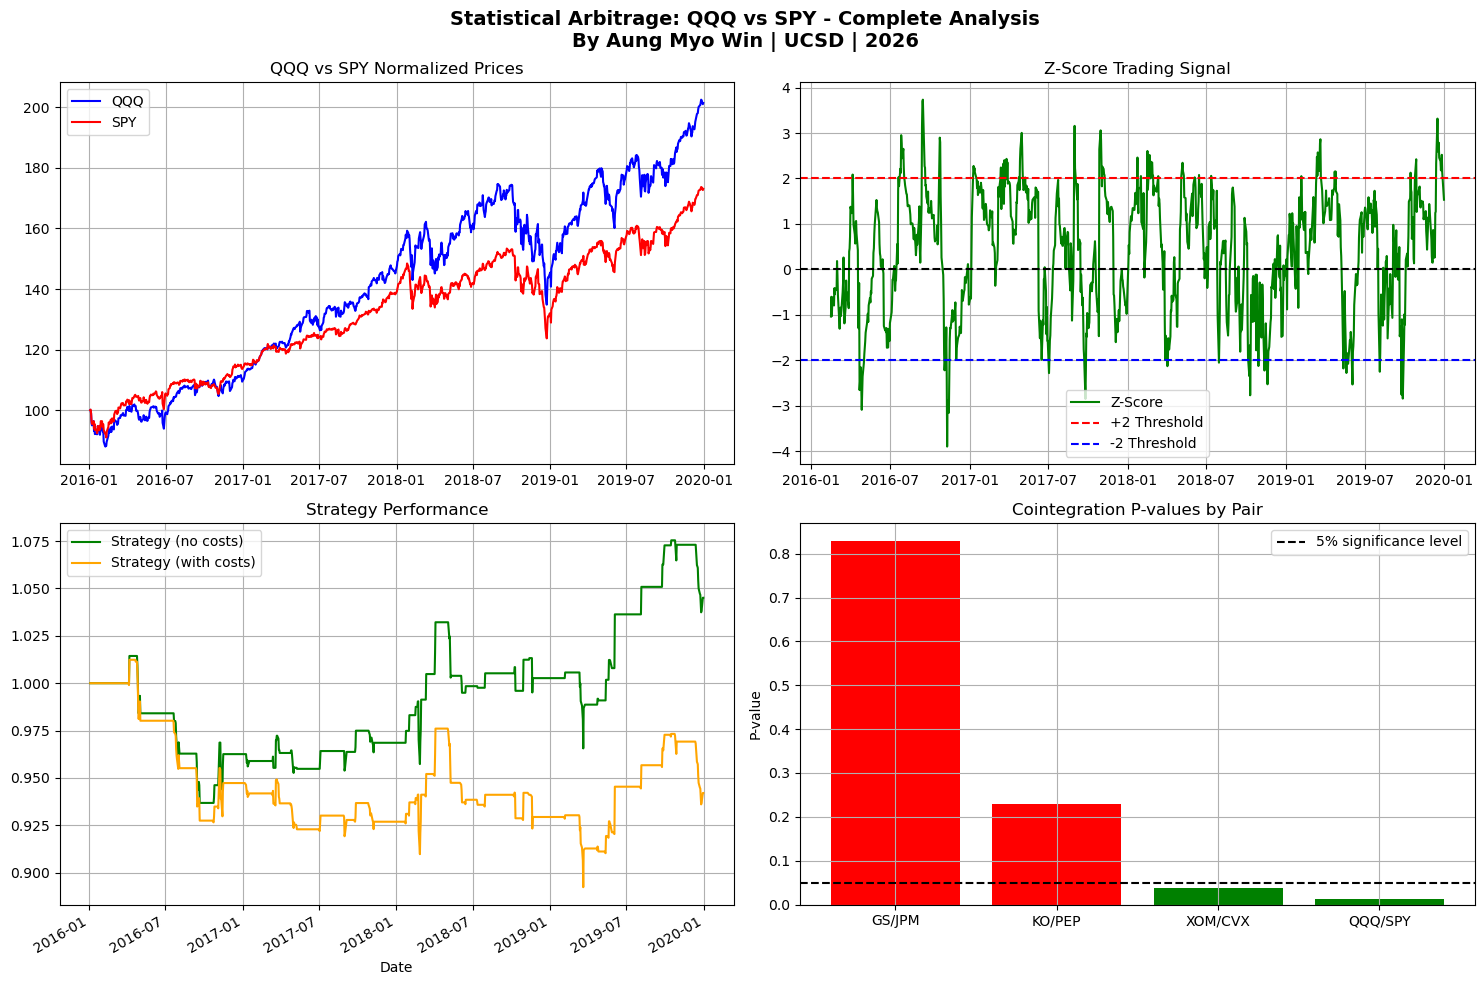

In [10]:
# Final Summary Chart
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Statistical Arbitrage: QQQ vs SPY - Complete Analysis\nBy Aung Myo Win | UCSD | 2026', 
             fontsize=14, fontweight='bold')

# Chart 1 — Price Comparison
ax1 = axes[0, 0]
qqq_norm = (qqq_price2 / qqq_price2.iloc[0]) * 100
spy_norm = (spy_price2 / spy_price2.iloc[0]) * 100
ax1.plot(qqq_norm, label='QQQ', color='blue')
ax1.plot(spy_norm, label='SPY', color='red')
ax1.set_title('QQQ vs SPY Normalized Prices')
ax1.legend()
ax1.grid(True)

# Chart 2 — Z-Score Signal
ax2 = axes[0, 1]
ax2.plot(zscore2, label='Z-Score', color='green')
ax2.axhline(y=2, color='red', linestyle='--', label='+2 Threshold')
ax2.axhline(y=-2, color='blue', linestyle='--', label='-2 Threshold')
ax2.axhline(y=0, color='black', linestyle='--')
ax2.set_title('Z-Score Trading Signal')
ax2.legend()
ax2.grid(True)

# Chart 3 — Strategy vs Buy & Hold
ax3 = axes[1, 0]
signals_tc['cumulative_no_cost'].plot(ax=ax3, label='Strategy (no costs)', color='green')
signals_tc['cumulative_with_cost'].plot(ax=ax3, label='Strategy (with costs)', color='orange')
ax3.set_title('Strategy Performance')
ax3.legend()
ax3.grid(True)

# Chart 4 — Pairs Comparison
ax4 = axes[1, 1]
pairs_data = {
    'GS/JPM': 0.8288,
    'KO/PEP': 0.2292,
    'XOM/CVX': 0.0380,
    'QQQ/SPY': 0.0132
}
colors = ['red', 'red', 'green', 'green']
bars = ax4.bar(pairs_data.keys(), pairs_data.values(), color=colors)
ax4.axhline(y=0.05, color='black', linestyle='--', label='5% significance level')
ax4.set_title('Cointegration P-values by Pair')
ax4.set_ylabel('P-value')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()